<a href="https://colab.research.google.com/github/sarmuh/Mushroom-Classification-ML/blob/main/Mushroom_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt
import sklearn

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix,precision_score,recall_score,f1_score,accuracy_score
from sklearn.inspection import permutation_importance

from sklearn.preprocessing import OneHotEncoder,LabelEncoder,OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline


from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier,plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

In [2]:
url="https://raw.githubusercontent.com/alishermutalov/praktikum-datasets/refs/heads/praktikum/mushrooms.csv"
df = pd.read_csv(url)
df.head()

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g


In [3]:
df.shape

(8124, 23)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8124 entries, 0 to 8123
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   class                     8124 non-null   object
 1   cap-shape                 8124 non-null   object
 2   cap-surface               8124 non-null   object
 3   cap-color                 8124 non-null   object
 4   bruises                   8124 non-null   object
 5   odor                      8124 non-null   object
 6   gill-attachment           8124 non-null   object
 7   gill-spacing              8124 non-null   object
 8   gill-size                 8124 non-null   object
 9   gill-color                8124 non-null   object
 10  stalk-shape               8124 non-null   object
 11  stalk-root                8124 non-null   object
 12  stalk-surface-above-ring  8124 non-null   object
 13  stalk-surface-below-ring  8124 non-null   object
 14  stalk-color-above-ring  

In [5]:
df.isnull().sum()

,0
class,0
cap-shape,0
cap-surface,0
cap-color,0
bruises,0
odor,0
gill-attachment,0
gill-spacing,0
gill-size,0
gill-color,0


In [6]:
df['class'].value_counts()

,count
class,
e,4208
p,3916


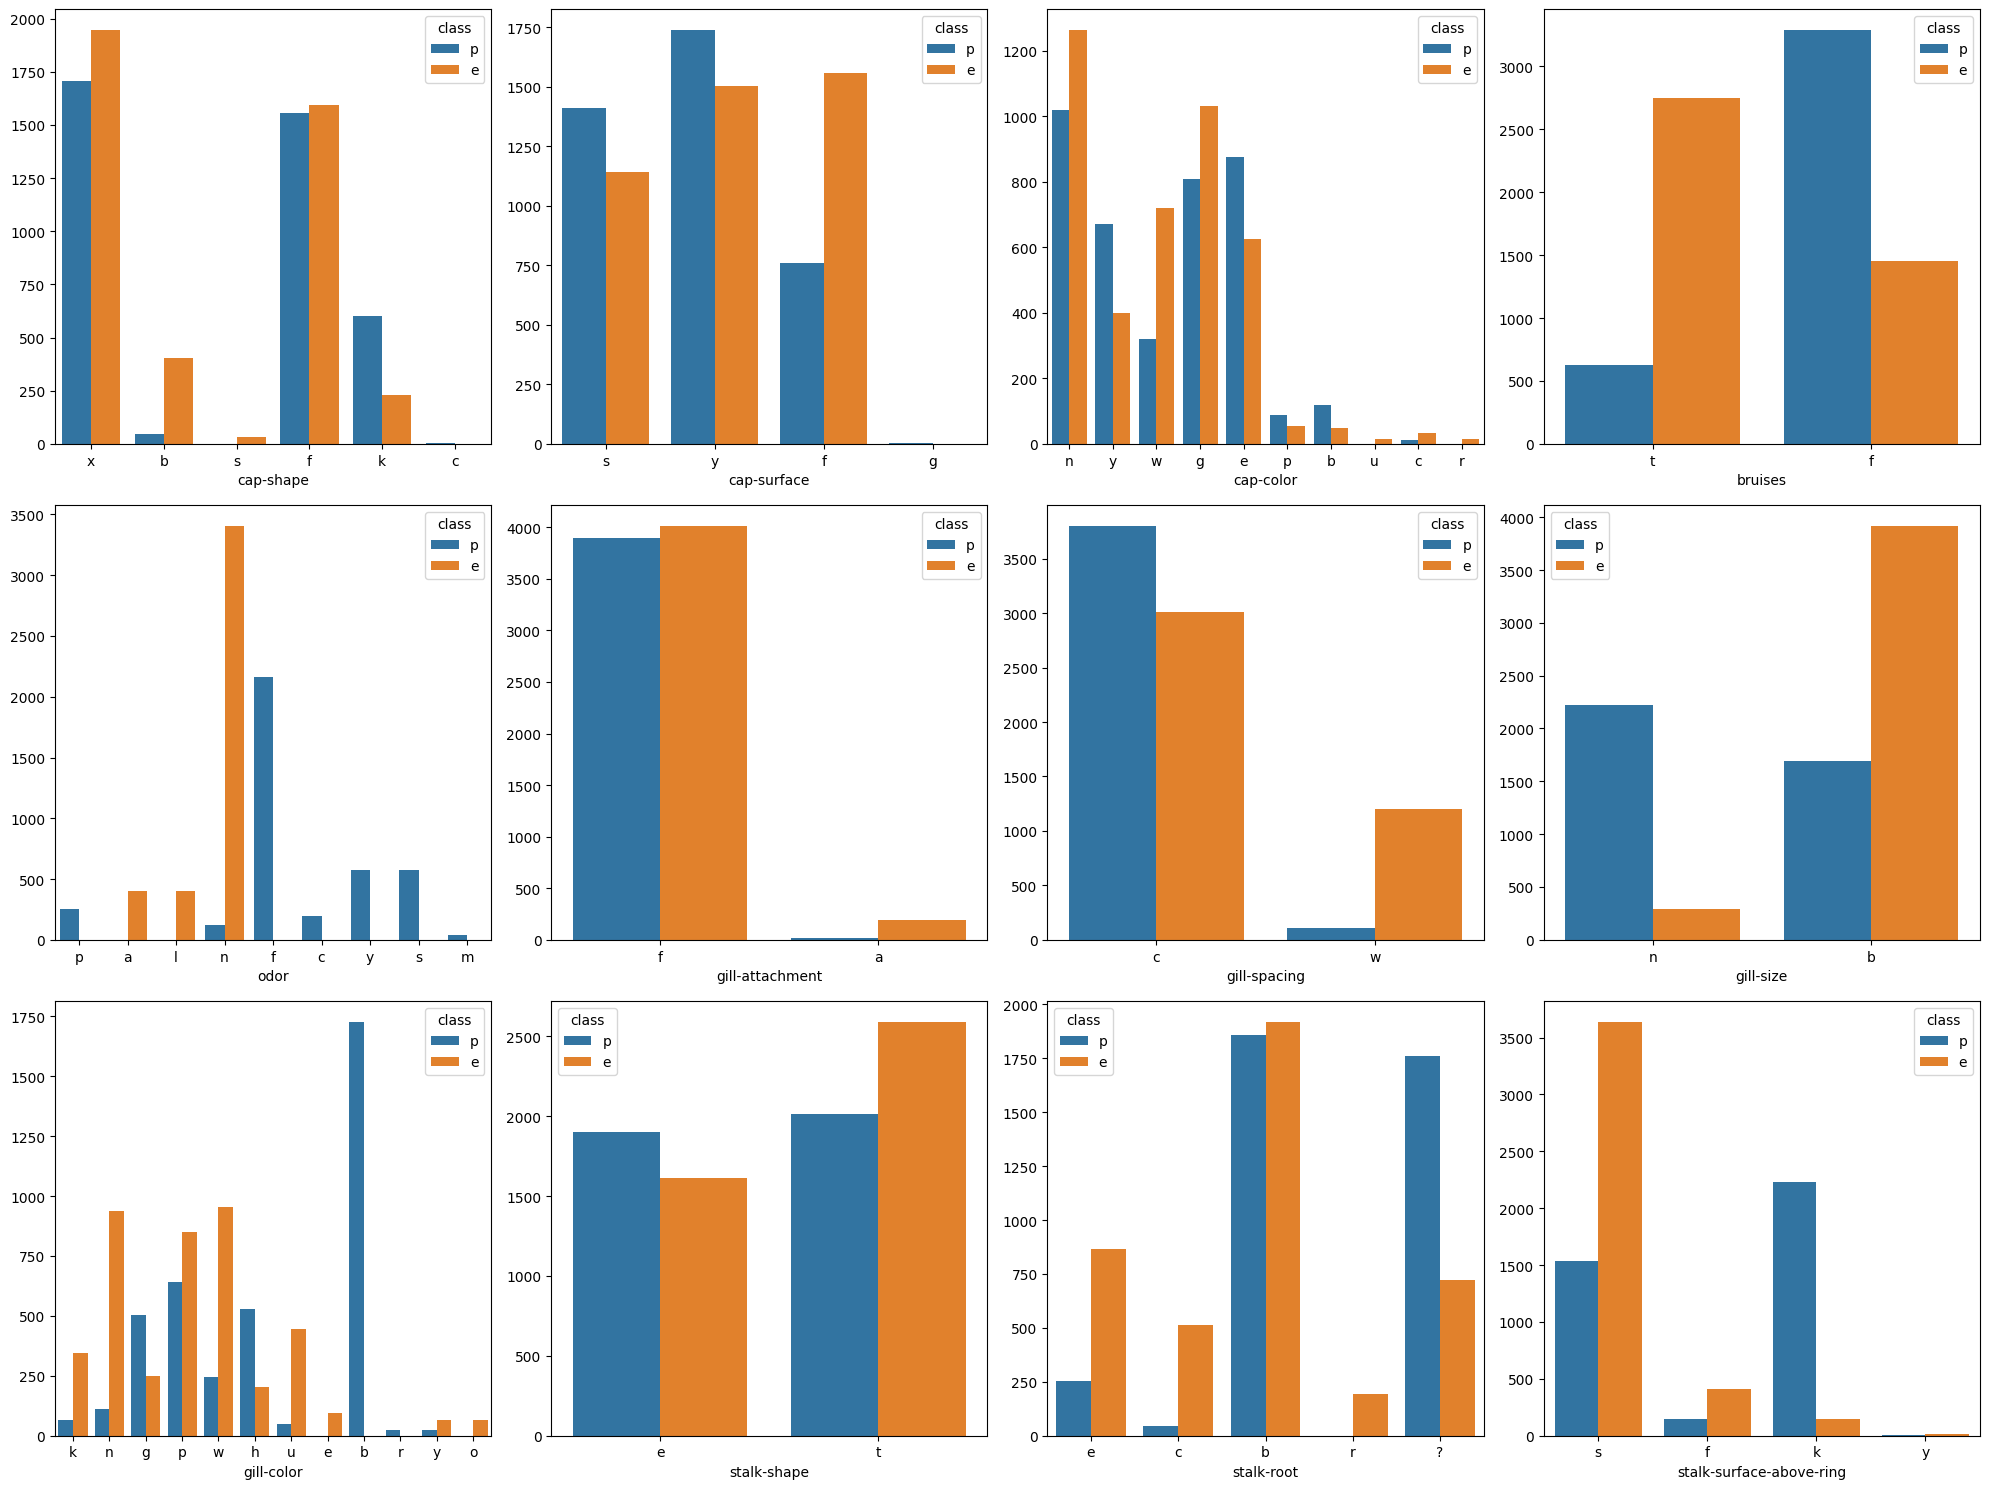

In [7]:
fig,ax = plt.subplots(3,4,figsize=(20,15))
ax = ax.flatten()
columns = df.columns[1:13]
for i,col in enumerate(columns):
  sns.countplot(data=df,x = col,ax=ax[i],hue='class')
  ax[i].set_ylabel('')
plt.tight_layout()
plt.show()

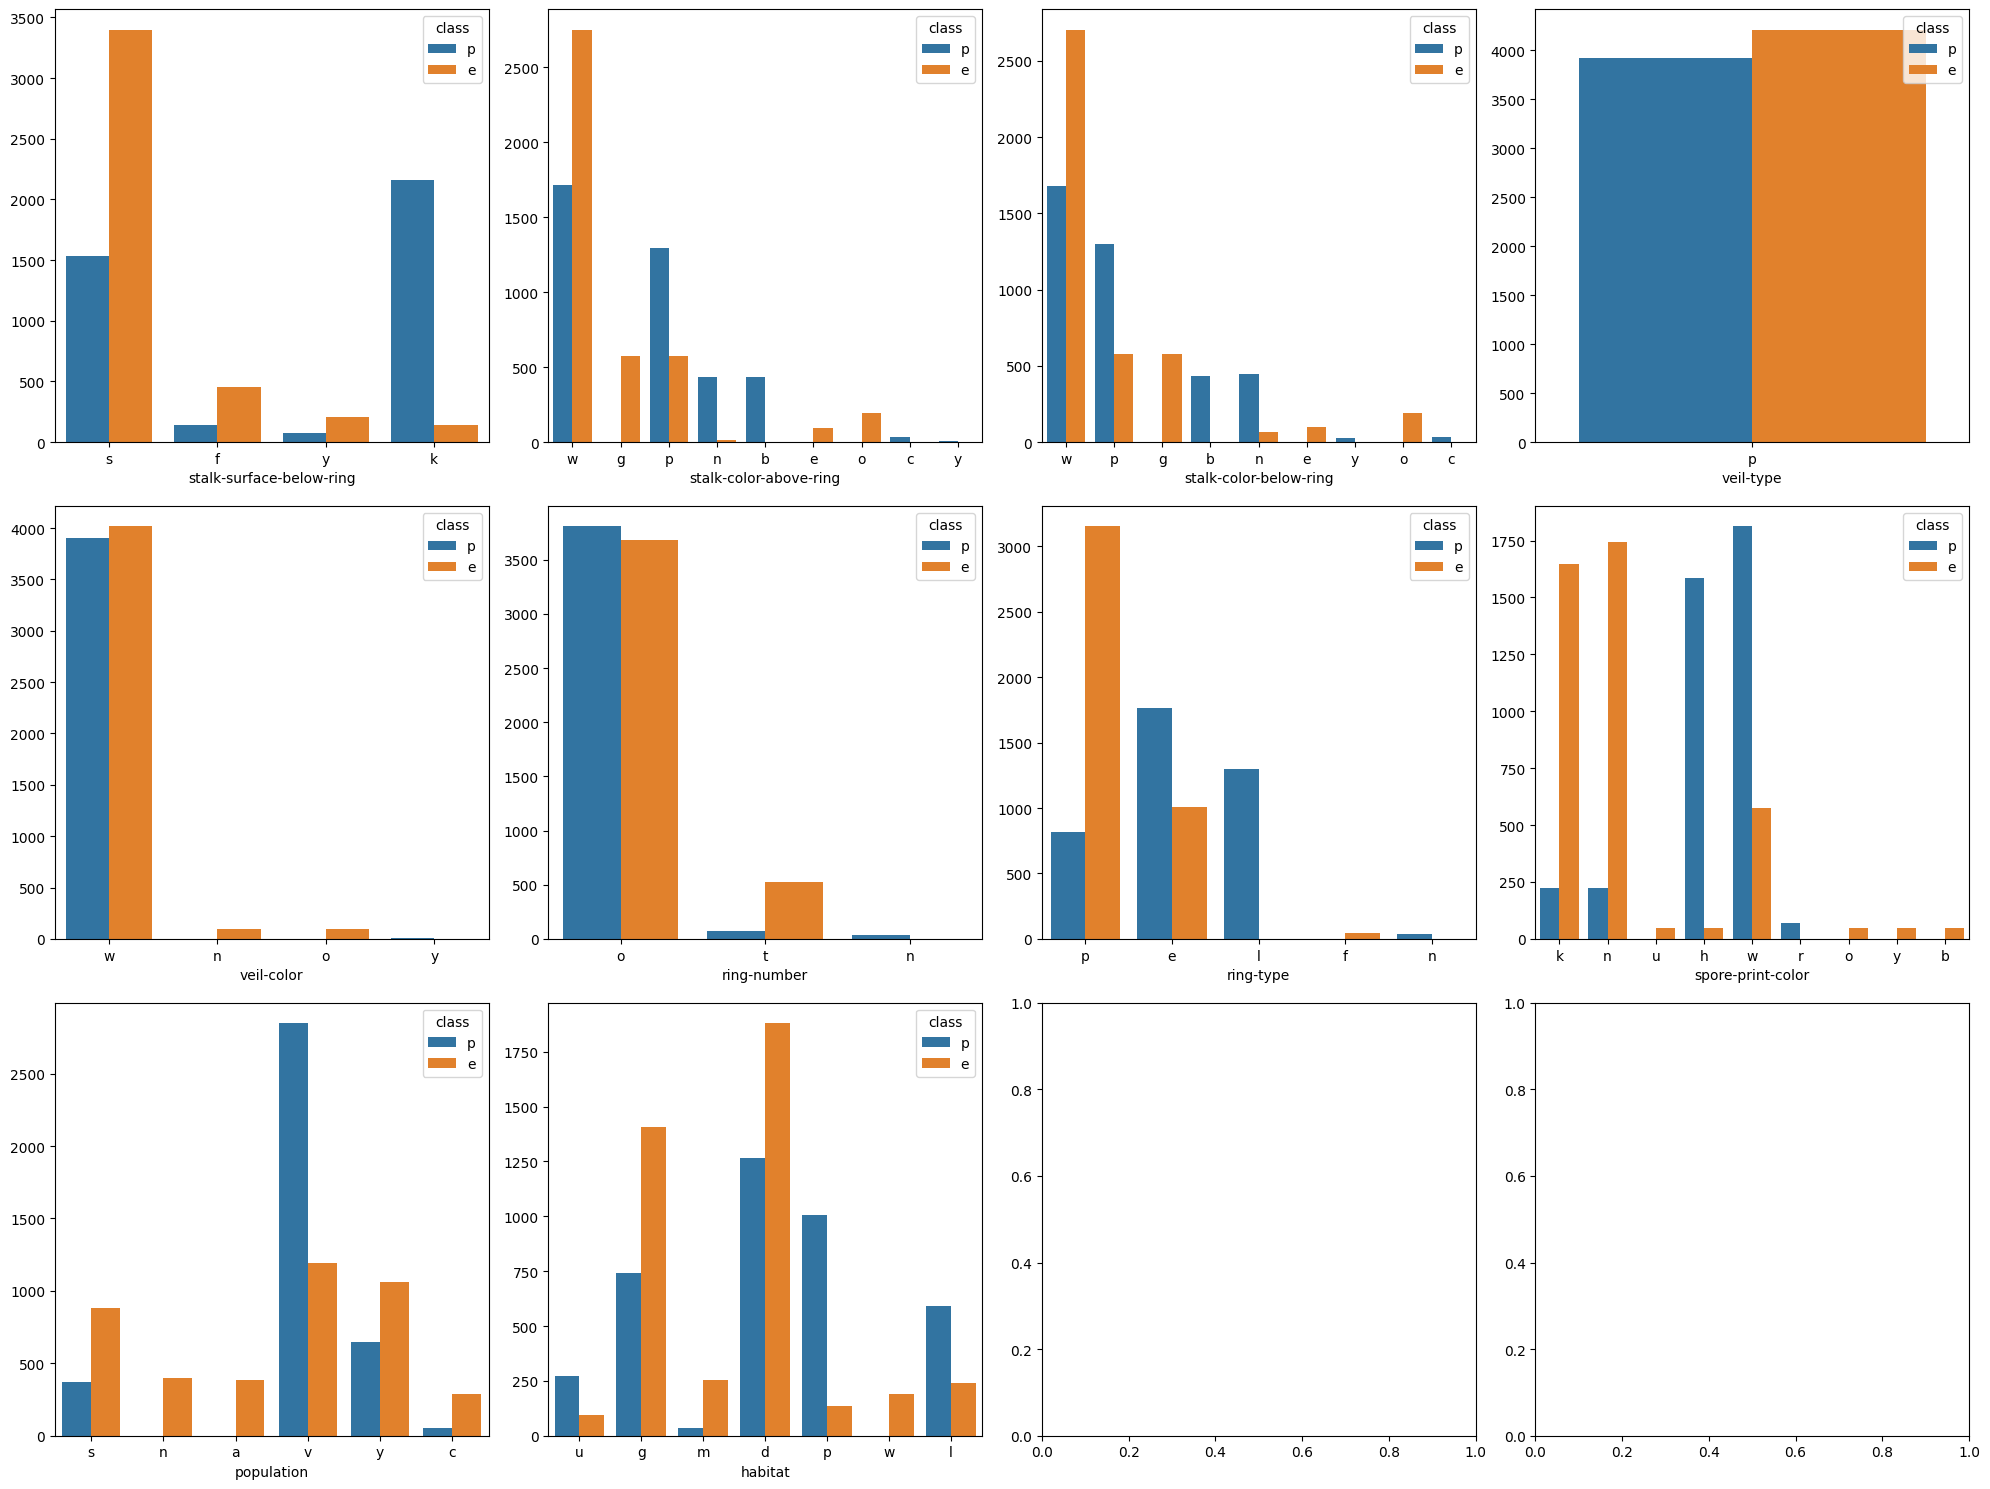

In [8]:
fig,ax = plt.subplots(3,4,figsize=(20,15))
ax = ax.flatten()
columns = df.columns[13:]
for i,col in enumerate(columns):
  sns.countplot(data=df,x = col,ax=ax[i],hue='class')
  ax[i].set_ylabel('')
plt.tight_layout()
plt.show()

In [9]:
df.drop('veil-type',axis=1,inplace=True )

In [10]:
df['gill-spacing'].value_counts() #izohda 3 ta class deyilgan

,count
gill-spacing,
c,6812
w,1312


In [11]:
X = df.drop('class',axis=1)
y = df['class']
y_encoder = LabelEncoder()
y = y_encoder.fit_transform(y)

In [12]:
y_encoder.classes_ #Zaharli 1,Zararsiz 0

array(['e', 'p'], dtype=object)

In [13]:
col_two = ['bruises', 'gill-size', 'gill-spacing', 'stalk-shape']
col_j = [col for col in X.columns.to_list() if col not in col_two]

In [14]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=0)
X_train.shape,X_test.shape,y_train.shape,y_test.shape

((6499, 21), (1625, 21), (6499,), (1625,))

In [15]:
prep = ColumnTransformer([
    ('ordinal-e',OrdinalEncoder(),col_two),
    ('onehot-e',OneHotEncoder(sparse_output=False),col_j)
])

In [16]:
X_train_processed = prep.fit_transform(X_train)
X_test_processed = prep.transform(X_test)

In [17]:
cols = prep.get_feature_names_out()
X_train_df = pd.DataFrame(X_train_processed,columns=cols)
X_train_df.iloc[1,:]

,1
ordinal-e__bruises,0.0
ordinal-e__gill-size,0.0
ordinal-e__gill-spacing,1.0
ordinal-e__stalk-shape,0.0
onehot-e__cap-shape_b,0.0
...,...
onehot-e__habitat_l,0.0
onehot-e__habitat_m,0.0
onehot-e__habitat_p,0.0
onehot-e__habitat_u,0.0


In [18]:
y_corr = pd.Series(y_train)
korr = abs(X_train_df.corrwith(y_corr).sort_values())
korr[:25]

,0
onehot-e__odor_n,0.788547
onehot-e__ring-type_p,0.531958
ordinal-e__bruises,0.498942
onehot-e__stalk-surface-above-ring_s,0.485065
onehot-e__stalk-surface-below-ring_s,0.419989
onehot-e__spore-print-color_n,0.412784
onehot-e__spore-print-color_k,0.397944
ordinal-e__gill-spacing,0.350821
onehot-e__gill-color_n,0.283557
onehot-e__stalk-color-below-ring_g,0.268338


In [19]:
models = {
    'Logistic Regression' : LogisticRegression(max_iter=100,n_jobs=-1),
    'Random Forest' : RandomForestClassifier(n_estimators=3,n_jobs=-1),
    'Decision Tree' : DecisionTreeClassifier(),
    'KNN': KNeighborsClassifier(n_neighbors=3,n_jobs=-1)
}

In [20]:
results = []


model_key = {
    'Logistic Regression': 'model_lr',
    'Random Forest': 'model_rf',
    'Decision Tree': 'model_dt',
    'KNN': 'model_knn'
}

for name,model in models.items():
  print(f'Training {name}')
  model.fit(X_train_processed,y_train)
  predt = model.predict(X_test_processed)

  Acc_score = accuracy_score(y_test,predt)
  Precision = precision_score(y_test,predt)
  Recall = recall_score(y_test,predt)
  F1 = f1_score(y_test,predt)

  results.append({
    "Model": name,
    "Acc_score" : Acc_score,
    'Precision': Precision,
    'Recall': Recall,
    'F1':F1
})
  var = model_key[name]
  globals()[var] = model

re_df = pd.DataFrame(results)

Training Logistic Regression
Training Random Forest
Training Decision Tree
Training KNN


In [21]:
re_df.sort_values(by=('Acc_score'))

,Model,Acc_score,Precision,Recall,F1
0,Logistic Regression,1.0,1.0,1.0,1.0
1,Random Forest,1.0,1.0,1.0,1.0
2,Decision Tree,1.0,1.0,1.0,1.0
3,KNN,1.0,1.0,1.0,1.0


In [22]:
from sklearn.model_selection import cross_validate
cross_validate(model_dt,X_train_processed,y_train,cv=5)

{'fit_time': array([0.17764592, 0.10041857, 0.10918093, 0.06126952, 0.06821299]),
 'score_time': array([0.01024771, 0.0052166 , 0.00403261, 0.00610828, 0.00407743]),
 'test_score': array([1., 1., 1., 1., 1.])}

In [23]:
from sklearn.model_selection import cross_validate
cross_validate(model_rf,X_train_processed,y_train,cv=5)

{'fit_time': array([0.08025026, 0.05255508, 0.09584022, 0.06344676, 0.07219863]),
 'score_time': array([0.0245471 , 0.02293777, 0.02795124, 0.02216744, 0.0195682 ]),
 'test_score': array([1., 1., 1., 1., 1.])}

In [24]:
# Har bir xususiyatning maqsad ustuniga ta'siri

columns = X_train_df.columns.str.replace("ordinal-e__", '',regex=False).str.replace("onehot-e__", '',regex=False)
dt_muh = model_dt.feature_importances_

dt_importance_df = pd.DataFrame({
    'Xususiyat': columns,
    "Ta'siri": dt_muh
})

dt_importance_df[dt_importance_df["Ta'siri"]>0].sort_values(by=("Ta'siri"))

,Xususiyat,Ta'siri
1,gill-size,0.000033
5,cap-shape_c,0.000615
0,bruises,0.001814
11,cap-surface_g,0.002454
64,stalk-color-above-ring_n,0.005794
97,spore-print-color_w,0.017707
24,odor_a,0.019509
27,odor_l,0.023817
95,spore-print-color_r,0.034527
59,stalk-surface-below-ring_y,0.102043


In [25]:
res = permutation_importance(model_dt,X_test_processed,y_test,n_repeats=7,random_state=42)
res['importances_mean']

perm_df = pd.DataFrame({
    'Xususiyat': columns,
    'Muhimlik': res.importances_mean
})
perm_df[perm_df['Muhimlik']>0].sort_values('Muhimlik')

,Xususiyat,Muhimlik
5,cap-shape_c,0.000176
64,stalk-color-above-ring_n,0.001934
0,bruises,0.009143
95,spore-print-color_r,0.010901
49,stalk-root_c,0.020308
97,spore-print-color_w,0.023912
27,odor_l,0.028747
59,stalk-surface-below-ring_y,0.030505
24,odor_a,0.039209
1,gill-size,0.070418


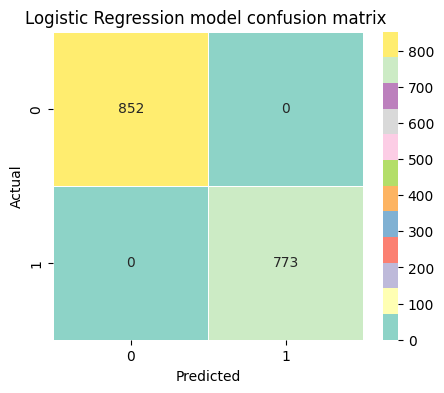

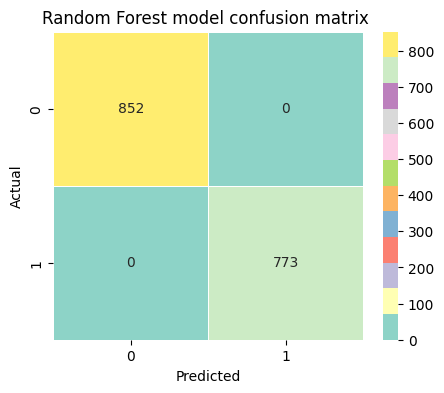

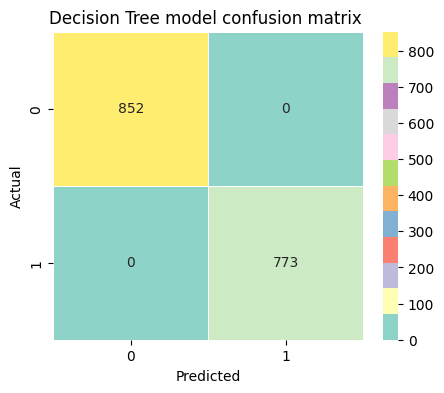

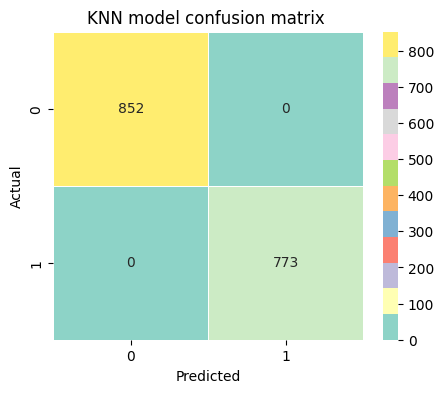

In [26]:
for name,model in model_key.items():
  model = globals()[model]
  y_pred = model.predict(X_test_processed)
  cm = confusion_matrix(y_test,y_pred)

  plt.figure(figsize=(5,4))
  sns.heatmap(data=cm,annot=True,linewidths=0.5,fmt='d',cmap='Set3')

  plt.title(f'{name} model confusion matrix ')
  plt.xlabel('Predicted')
  plt.ylabel('Actual')

  plt.show()

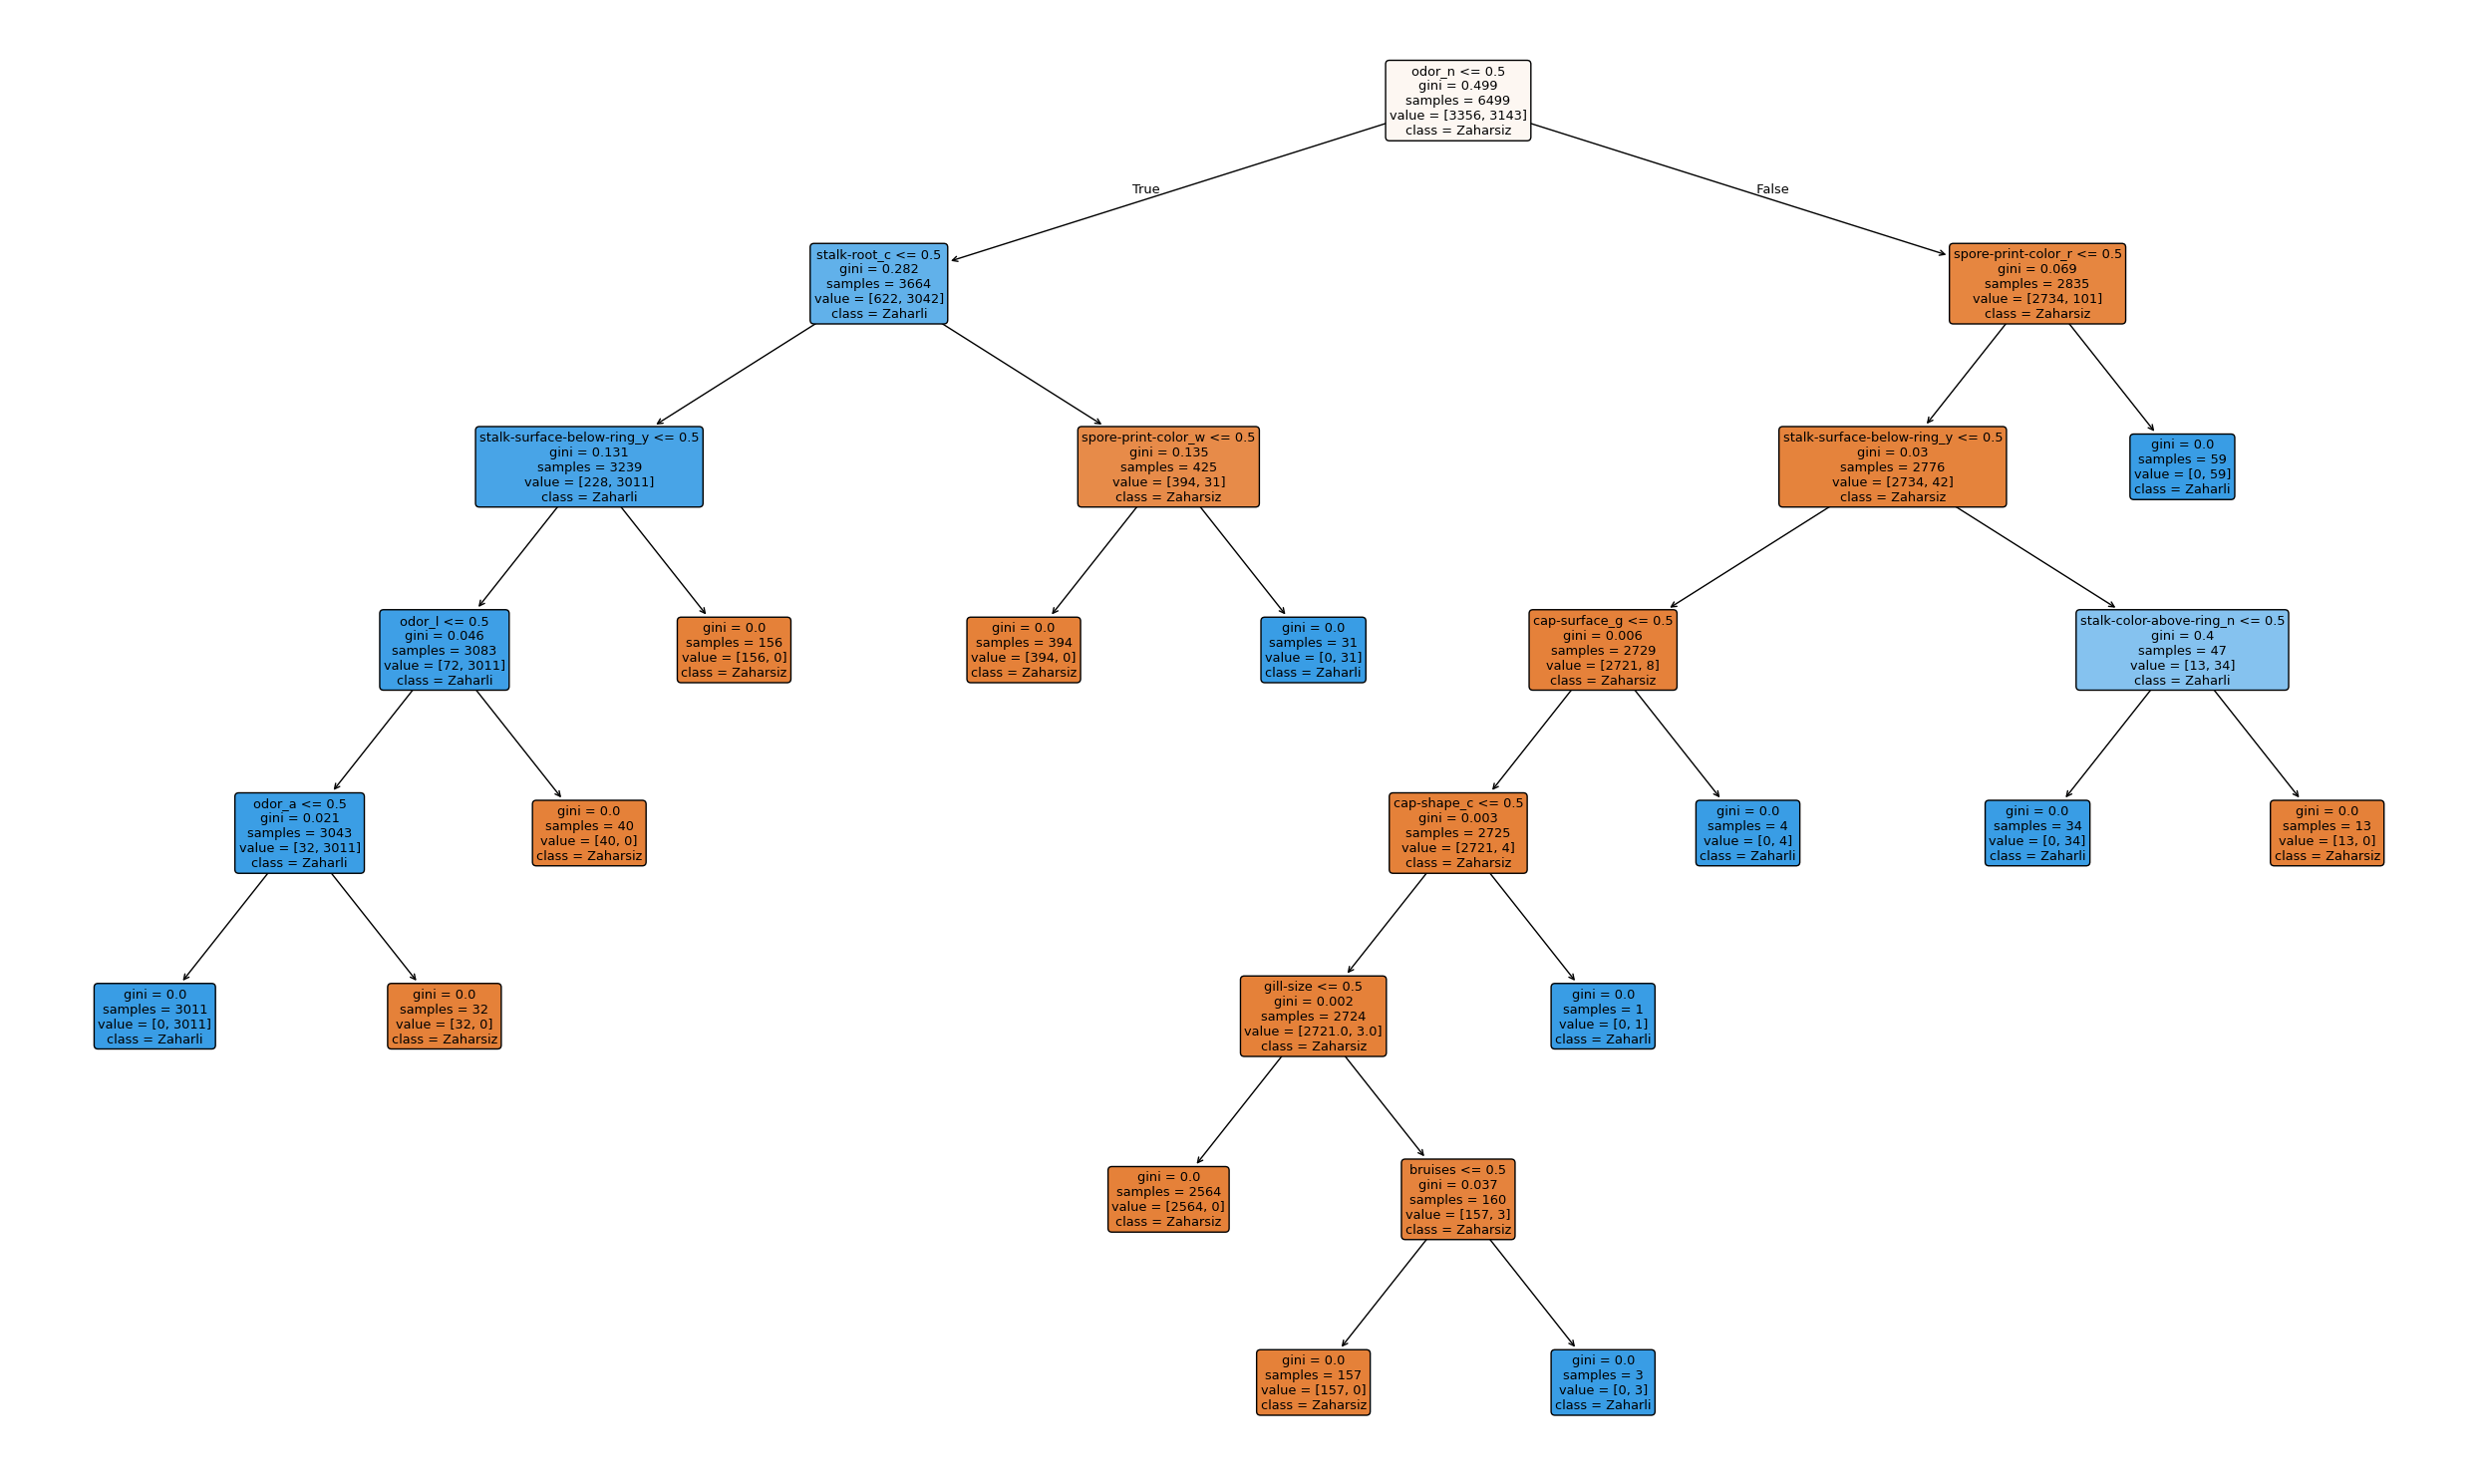

In [28]:
fn = columns
cn = ['Zaharsiz','Zaharli']
plt.figure(figsize=(25,15))
plot_tree(model_dt,feature_names=fn,class_names=cn,filled=True,rounded=True)

plt.tight_layout()
plt.show()

#**Xulosa**
* *Barcha modellar 100% natija ko'rsatdi.*
* *Bular ichidan **tezligi** bo'yicha Decision Tree	tanlab olish kerak chunki bitta daraxt 100% natija bilan ishlamoqda.*
* *Agar natija past bo'lganda qaytadan * Future engenering qilish,ustunlani kamaytirish, hyperparametr tuning qilish (GridSearch,RandomizedSearch .h.k)*